In [1]:
#risk analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url1="https://raw.githubusercontent.com/KarthikaDornipadu/alpha-pulse-financial-analytics/refs/heads/master/Data/clean_prices.csv"
url2="https://raw.githubusercontent.com/KarthikaDornipadu/alpha-pulse-financial-analytics/refs/heads/master/Data/portfolio.csv"
df=pd.read_csv(url1)
weights_df=pd.read_csv(url2)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [7]:
#daily returns
returns=df.pct_change().dropna()
returns.to_csv('daily_returns.csv')
print('Daily returns saved to daily_returns.csv')

Daily returns saved to daily_returns.csv


In [3]:
weights=pd.read_csv(url2)
weights['weight']=weights['weight']/weights['weight'].sum()
weights = weights.set_index('Stocks')['weight']
print(weights.sum())
weights = weights.reindex(df.columns)
portfolio_returns = returns.dot(weights)
mean=portfolio_returns.mean()
print("mean:",mean)
std=portfolio_returns.std()
print("std:",std)

expected_return= portfolio_returns.mean()
print("expected daily return:",expected_return)

1.0
mean: 0.001090365293334896
std: 0.014825387172177913
expected daily return: 0.001090365293334896


In [8]:
portfolio_returns.to_csv('portfolio_returns.csv')
print('Portfolio returns saved to portfolio_returns.csv')

Portfolio returns saved to portfolio_returns.csv


In [4]:
cov_matrix = returns.cov()

portfolio_volatility = np.sqrt(
    np.dot(weights.T, np.dot(cov_matrix, weights))
)

print("Portfolio Volatility:", portfolio_volatility)
trading_days = 252

annual_return = expected_return * trading_days
annual_volatility = portfolio_volatility * np.sqrt(trading_days)

print("Annual Return:", annual_return)
risk_free_rate = 0.02  # 2% assumption

sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

print("Sharpe Ratio:", sharpe_ratio)

Portfolio Volatility: 0.014825387172177913
Annual Return: 0.2747720539203938
Sharpe Ratio: 1.0825437921582222


In [5]:
import pandas as pd
import numpy as np

prices = pd.read_csv(url1, index_col='Date')

# Log returns
log_returns = np.log(prices / prices.shift(1)).dropna()

# Correlation
corr = log_returns.corr()

# Rolling volatility
rolling_vol = portfolio_returns.rolling(30).std()
#var
Var_95=np.percentile(portfolio_returns,5)
print('Var_95:',Var_95)

# Save outputs
log_returns.to_csv("log_returns.csv")
corr.to_csv("correlation.csv")
rolling_vol.to_csv("volatility.csv")

Var_95: -0.02154022873817627


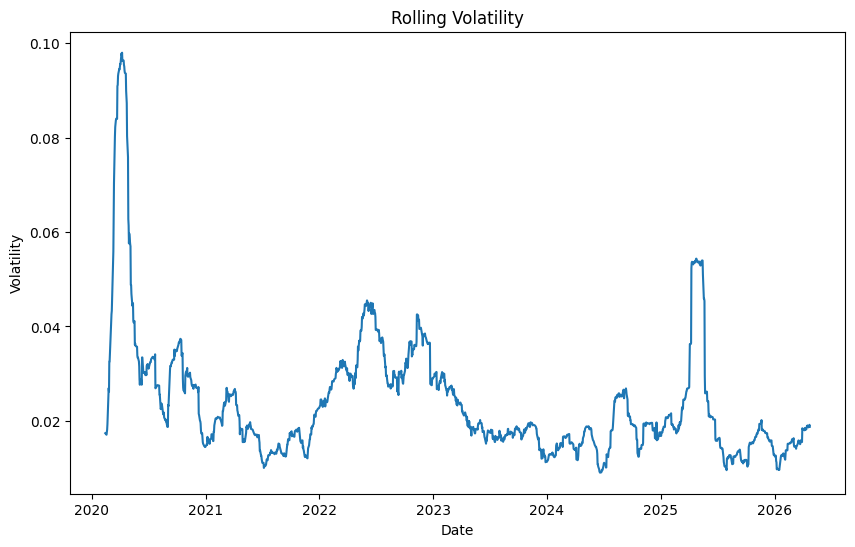

In [ ]:
#Rolling volatility plot
plt.figure(figsize=(10,6))
plt.plot(rolling_vol)
plt.title('Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

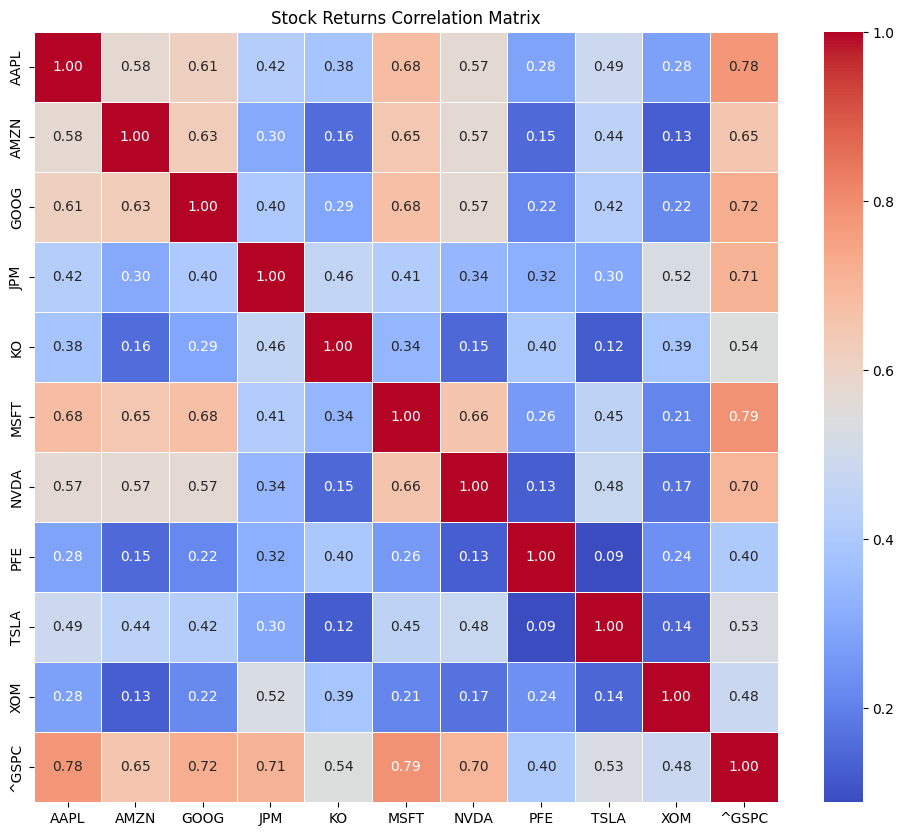

In [ ]:
#Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix of the individual stock returns
correlation_matrix = returns.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Stock Returns Correlation Matrix')
plt.show()

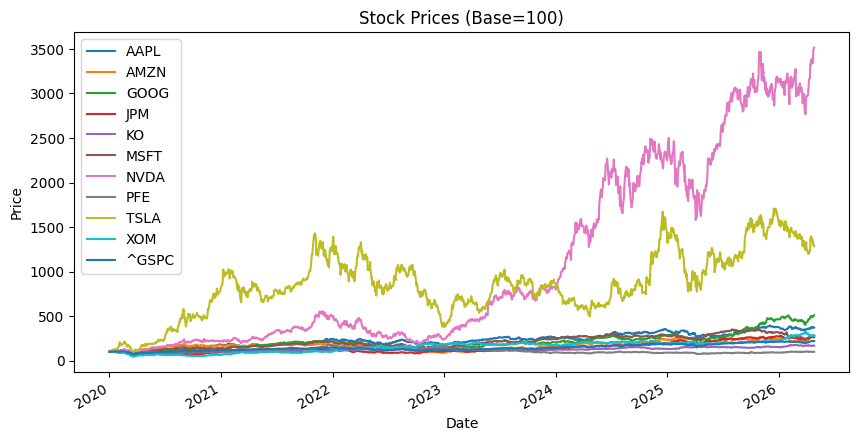

In [ ]:
#stock price plot
normalized=(df / df.iloc[0]) * 100
normalized.plot(figsize=(10,5))
plt.title('Stock Prices (Base=100)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [6]:
import pandas as pd
url3="https://raw.githubusercontent.com/KarthikaDornipadu/alpha-pulse-financial-analytics/refs/heads/master/Data/stock_data.csv"
data=pd.read_csv(url3,header=[0,1],index_col=0)
volume = data.xs('Volume', level=0, axis=1)
volume.to_csv("clean_volume.csv")

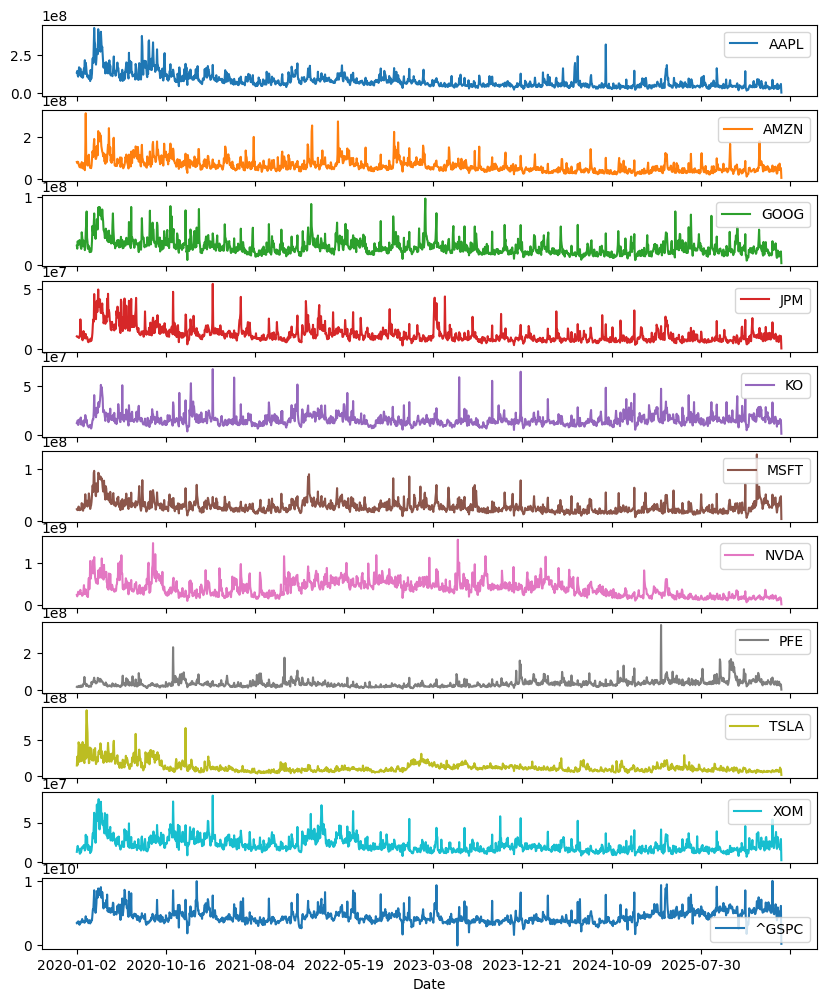

In [22]:
volume.plot(subplots=True,figsize=(10,12))
plt.show()


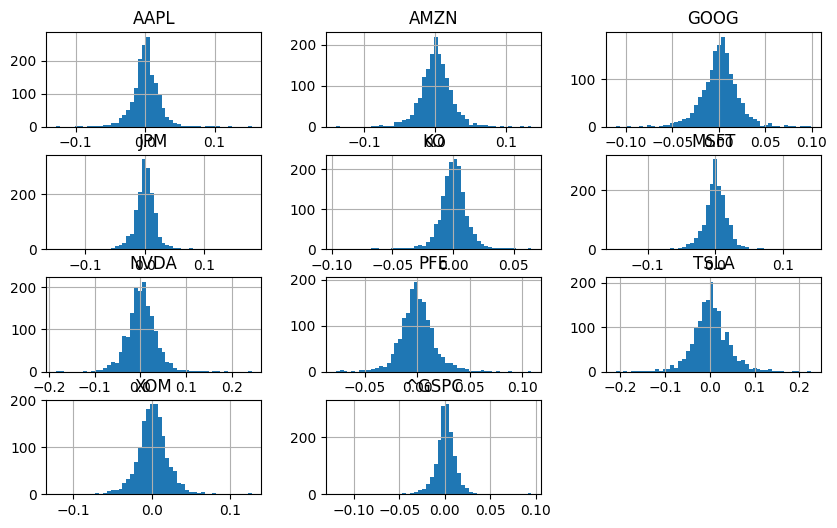

In [ ]:
#daily_returns
returns.hist(bins=50, figsize=(10,6))
plt.title('Distribution of Returns')
plt.show()